# Simulations With Multiple Sets of Particles

You may want to include multiple sets of particles in your simulation that are handled differently. 

## Adding Multiple Sets of Particles

Adding multiple sets of particles works just like [adding an individual set](setting_up_a_simulation.ipynb#adding-particles-to-your-simulation), as long as the provided name is different than that of the existing components.

In [97]:
from tambora.simulation import Sim
from tambora.tools import mkPlummer_galpy

# --- ICs for two sets of particles -------------- #
pos1, vel1, mass1 = mkPlummer_galpy(1e9, b=3, n=1000, center_pos=[-5, -5, 0], center_vel=[20, 0, 0])
pos2, vel2, mass2 = mkPlummer_galpy(1e9, b=1, n=1000, center_pos=[5, 5, 0], center_vel=[-20, 0, 0])

# --- Add both sets of particles to the simulation --- #
mysim = Sim() 
mysim.add_particles('set1', pos1, vel1, mass1)
mysim.add_particles('set2', pos2, vel2, mass2)

In [94]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

prog_host_orbs = Sim()
prog_host_orbs.add_particles('host', [np.mean(pos1, axis=0)], [np.mean(vel1, axis=0)], [np.sum(mass1)])
prog_host_orbs.add_particles('sat', [np.mean(pos2, axis=0)], [np.mean(vel2, axis=0)], [np.sum(mass2)])
prog_host_orbs.run(t_end=0.4, dt=0.001, dt_out=0.01, eps=0.01)



100%|██████████| 400/400 [00:00<00:00, 26217.68it/s]


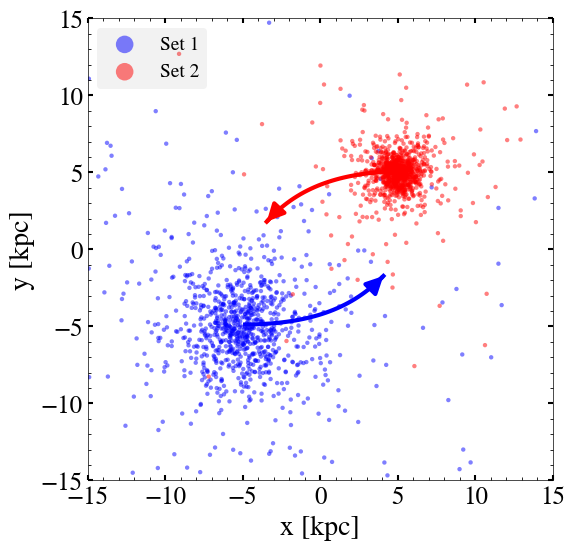

In [101]:
plt.figure(figsize=(6, 6))
def plot_orbit(orbit, color, lw=3):
    x, y = orbit.x(), orbit.y()
    plt.plot(x, y, c=color, alpha=1.0, lw=lw)
    plt.annotate(
        "", xy=(x[-1], y[-1]), xytext=(x[-2], y[-2]),
        arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=25),
    )
plot_orbit(prog_host_orbs.host, "blue")
plot_orbit(prog_host_orbs.sat, "red")

plt.scatter(mysim.set1.x(0), mysim.set1.y(0), s=10, alpha=0.5, c='blue', label='Set 1')
plt.scatter(mysim.set2.x(0), mysim.set2.y(0), s=10, alpha=0.5, c='red', label='Set 2')
plt.xlim(-15, 15)
plt.ylim(-15, 15)
plt.xlabel('x [kpc]', fontsize=20)
plt.ylabel('y [kpc]', fontsize=20)
plt.legend(fontsize=14, loc='upper left', markerscale=4)
plt.show()

100%|██████████| 400/400 [00:00<00:00, 31481.09it/s]


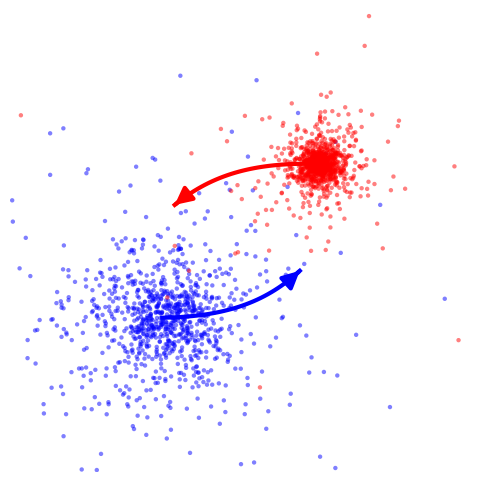

In [ ]:
plt.figure(figsize=(6, 6))
def plot_orbit(orbit, color, lw=3):
    x, y = orbit.x(), orbit.y()
    plt.plot(x, y, c=color, alpha=1.0, lw=lw)
    plt.annotate(
        "", xy=(x[-1], y[-1]), xytext=(x[-2], y[-2]),
        arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=25),
    )
plot_orbit(prog_host_orbs.host, "blue")
plot_orbit(prog_host_orbs.sat, "red")

plt.scatter(mysim.host.x(0), mysim.host.y(0), s=10, alpha=0.5, c='blue')
plt.scatter(mysim.sat.x(0), mysim.sat.y(0), s=10, alpha=0.5, c='red')
plt.xlim(-15, 15)
plt.ylim(-15, 15)
plt.axis('off')
plt.savefig('multicomponent_IC.png', bbox_inches='tight', pad_inches=0, dpi=150)

**NOTE**: Need to add a method that lists the names of existing components. Also add check that the pos, vel, and masses the user is attempting to add does not overlap with an existing component.

## Accessing Properties of Individual Components
🚧 *Still working on it...* 🚧